I am going to use Random Search to do initial attempts at hyperparameter optimization. I've chosen Random Search instead of Grid Search because it takes less compute time and produces similar results.

Random Search Optimization uses the following steps which I will apply to my Cabo model using python (https://medium.com/@ergen5171/random-search-optimization-algorithm-048072caea84):

1. Define the function to be optimized.
Win rate of the agent over 20 games.
2. Set search space boundaries.
3. Generate random candidate solutions within the boundaries.
4. Evaluate each candidate using the objective function.
5. Track the best solution found so far.
6. Repeat for a predefined number of iterations.
500 iterations.

I ran 500 iterations with 20 games played in each iteration. For each iteration, the 20 games were seeded the same to give each space boundary combination constant conditions to compare win rate. The "tuned" opponent played against my initial heuristic opponent.

The "first_combination" oppoonent found that the best combo was {'swap_margin': 0.9914362231109511, 'who_has_seen_opponent_card': 3, 'who_has_seen_my_card': 1, 'cabo_known_ratio_threshold': 0.613449352799165, 'cabo_avg_value_threshold': 5.7602470927440885}.

This resulted in a win rate of 50%! 

I ran 1000 games of just this first combination and got a win rate of 37.8%! So, it performs better than my hardcoded strategy! Can we get it to be better than this? Below is showing how well this initial combination performed.

In [9]:
import glob
import pandas as pd

files = glob.glob("../backend/app/game_logs/random_search_opponent/first_combo/games_w_combo/*.jsonl")
print(f"{len(files)} game files found")

dfs = [pd.read_json(f, lines=True) for f in files] #each line becomes a df
events = pd.concat(dfs, ignore_index=True) #stacks the indvidual df into one combined df

1000 game files found


Text(0, 0.5, 'Number of wins')

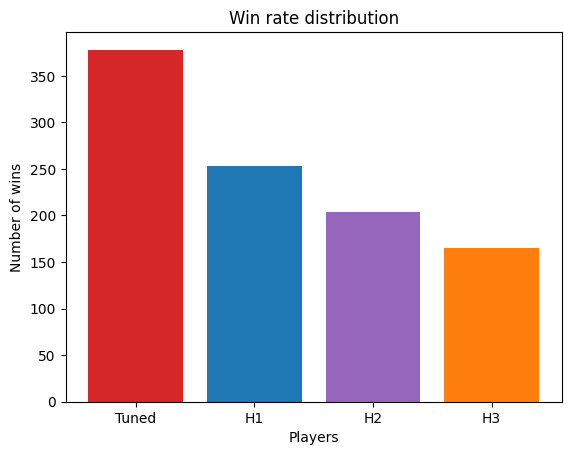

In [10]:

import matplotlib.pyplot as plt
final_winners = events[events.event_type == "final_winner"]

wins = []
players = ["Tuned", "H1", "H2", "H3" ]
for player in players:
    wins.append(final_winners[final_winners.player == player].shape[0])

#can also be done finalwinners.groupby("players").size()
bar_colors = ['tab:red', 'tab:blue', 'tab:purple', 'tab:orange']
plt.bar(players, wins, color = bar_colors)
plt.title("Win rate distribution")
plt.xlabel("Players")
plt.ylabel("Number of wins")

Let's look at which combination factors actually correlated with win rate!

   swap_margin  who_has_seen_opponent_card  who_has_seen_my_card  \
0     1.514901                           4                     3   
1     0.618147                           4                     4   
2     1.696410                           1                     4   
3     0.506520                           3                     4   
4     0.797734                           2                     3   

   cabo_known_ratio_threshold  cabo_avg_value_threshold  win_rate  trial  
0                    0.566163                  2.177660      0.10      0  
1                    0.981373                  3.426532      0.15      1  
2                    0.993429                  4.001228      0.00      2  
3                    0.940093                  4.825202      0.15      3  
4                    0.890749                  5.079192      0.05      4  


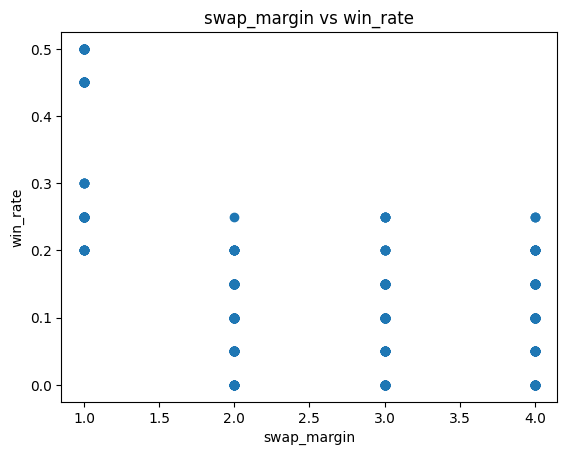

In [16]:
df = pd.read_csv("../backend/app/game_logs/random_search_opponent/summary_combos/search_results.csv")
print(df.head())

plt.scatter(df["who_has_seen_my_card"], df["win_rate"])
plt.xlabel("swap_margin")
plt.ylabel("win_rate")
plt.title("swap_margin vs win_rate")
plt.show()
